## BiLSTM-CRF + CharCNN
Word-level BiLSTM + CRF with character-level CNN embeddings.

In [2]:
import numpy as np
import pickle
import json
import random
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cpu
PyTorch : 2.12.0+cpu


### Load data

In [3]:
DATA_DIR  = Path('../../datasets/processed_data')
SPLIT_DIR = Path('../../datasets/split_data')

X_tokens_train = np.load(DATA_DIR / 'X_tokens_train.npy')
X_chars_train  = np.load(DATA_DIR / 'X_chars_train.npy')
Y_labels_train = np.load(DATA_DIR / 'Y_labels_train.npy')
masks_train    = np.load(DATA_DIR / 'masks_train.npy')

X_tokens_val   = np.load(DATA_DIR / 'X_tokens_val.npy')
X_chars_val    = np.load(DATA_DIR / 'X_chars_val.npy')
Y_labels_val   = np.load(DATA_DIR / 'Y_labels_val.npy')
masks_val      = np.load(DATA_DIR / 'masks_val.npy')

X_tokens_test  = np.load(DATA_DIR / 'X_tokens_test.npy')
X_chars_test   = np.load(DATA_DIR / 'X_chars_test.npy')
Y_labels_test  = np.load(DATA_DIR / 'Y_labels_test.npy')
masks_test     = np.load(DATA_DIR / 'masks_test.npy')

emb_mat = np.load(DATA_DIR / 'embedding_matrix.npy')

with open(DATA_DIR / 'vocabs.pkl', 'rb') as f:
    vocabs = pickle.load(f)

token2id      = vocabs['token2id']
id2token      = vocabs['id2token']
label2id      = vocabs['label2id']
id2label      = vocabs['id2label']
char2id       = vocabs['char2id']
PAD_ID        = vocabs['PAD_ID']
UNK_ID        = vocabs['UNK_ID']
PAD_LABEL_ID  = vocabs['PAD_LABEL_ID']
Entity_labels = vocabs['Entity_labels']
MAX_LEN       = vocabs['MAX_LEN_LSTM']
EMBED_DIM     = vocabs['EMBED_DIM']

NUM_LABELS = len(label2id)
CHAR_SIZE  = len(char2id)
MAX_CHAR   = X_chars_train.shape[2]

with open(SPLIT_DIR / 'split_indices.json') as f:
    split_idx = json.load(f)
idx_train = split_idx['idx_train']
idx_val   = split_idx['idx_val']
idx_test  = split_idx['idx_test']
idx_train_balanced = split_idx['idx_train_balanced']

print(f'Train / Val / Test : {len(idx_train)} / {len(idx_val)} / {len(idx_test)}')
print(f'Train balanced     : {len(idx_train_balanced)}')
print(f'X_tokens_train     : {X_tokens_train.shape}')
print(f'X_chars_train      : {X_chars_train.shape}')
print(f'Vocab size         : {len(token2id):,}')
print(f'Char vocab         : {CHAR_SIZE}')
print(f'Num labels         : {NUM_LABELS}')

Train / Val / Test : 154 / 33 / 33
Train balanced     : 300
X_tokens_train     : (300, 256)
X_chars_train      : (300, 256, 20)
Vocab size         : 3,378
Char vocab         : 59
Num labels         : 22


### Dataset & DataLoader

In [4]:
class ResumeNERDataset(Dataset):
    """Dataset with token + char IDs."""
    def __init__(self, X_tokens, X_chars, Y_labels, masks):
        self.X_tokens = torch.tensor(X_tokens, dtype=torch.long)
        self.X_chars  = torch.tensor(X_chars,  dtype=torch.long)
        self.Y_labels = torch.tensor(Y_labels, dtype=torch.long)
        self.masks    = torch.tensor(masks,    dtype=torch.bool)

    def __len__(self):
        return len(self.X_tokens)

    def __getitem__(self, idx):
        return self.X_tokens[idx], self.X_chars[idx], self.Y_labels[idx], self.masks[idx]


BATCH_SIZE = 32

train_ds = ResumeNERDataset(X_tokens_train, X_chars_train, Y_labels_train, masks_train)
val_ds   = ResumeNERDataset(X_tokens_val,   X_chars_val,   Y_labels_val,   masks_val)
test_ds  = ResumeNERDataset(X_tokens_test,  X_chars_test,  Y_labels_test,  masks_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 300 | Val: 33 | Test: 33


### Model

In [5]:
from torchcrf import CRF


class CharCNN(nn.Module):
    """Character-level CNN → fixed-size embedding per token."""
    def __init__(self, char_vocab_size, char_embed_dim=30, out_channels=50, kernel_size=3):
        super().__init__()
        self.embed = nn.Embedding(char_vocab_size, char_embed_dim, padding_idx=0)
        self.conv  = nn.Conv1d(char_embed_dim, out_channels, kernel_size, padding=kernel_size//2)
        self.relu  = nn.ReLU()

    def forward(self, char_ids):
        B, L, C = char_ids.shape
        x = char_ids.view(B * L, C)
        x = self.embed(x).permute(0, 2, 1)   # (B*L, E_c, C)
        x = self.relu(self.conv(x))           # (B*L, out_ch, C)
        x = x.max(dim=-1).values              # (B*L, out_ch)
        return x.view(B, L, -1)              # (B, L, out_ch)


class BiLSTM_CRF(nn.Module):
    """
    BiLSTM-CRF with CharCNN for NER.

    Pipeline
    --------
    Token IDs → FastText word embeddings  ┐
    Char IDs  → CharCNN char embeddings   ├─ concat → BiLSTM → Linear → CRF
    """

    def __init__(
        self,
        embedding_matrix  : np.ndarray,
        char_vocab_size   : int,
        num_tags          : int,
        pad_token_id      : int,
        pad_tag_id        : int,
        hidden_dim        : int   = 256,
        num_layers        : int   = 2,
        char_embed_dim    : int   = 30,
        char_out_channels : int   = 50,
        kernel_size       : int   = 3,
        dropout           : float = 0.5,
        freeze_embeddings : bool  = False,
    ):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        self.word_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_token_id)
        self.word_emb.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            requires_grad=not freeze_embeddings
        )

        self.char_cnn = CharCNN(char_vocab_size, char_embed_dim, char_out_channels, kernel_size)
        self.dropout  = nn.Dropout(dropout)

        lstm_input = embed_dim + char_out_channels
        self.lstm = nn.LSTM(
            input_size=lstm_input,
            hidden_size=hidden_dim // 2,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.fc  = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)
        self.pad_tag_id = pad_tag_id

    def _get_emissions(self, token_ids, char_ids, mask):
        word_x = self.dropout(self.word_emb(token_ids))   # (B, L, E)
        char_x = self.dropout(self.char_cnn(char_ids))    # (B, L, char_out)
        x = torch.cat([word_x, char_x], dim=-1)           # (B, L, E+char_out)
        x, _ = self.lstm(x)
        x = self.dropout(x)
        return self.fc(x)

    def forward(self, token_ids, char_ids, labels, mask):
        emissions = self._get_emissions(token_ids, char_ids, mask)
        return -self.crf(emissions, labels, mask=mask, reduction='mean')

    @torch.no_grad()
    def decode(self, token_ids, char_ids, mask):
        emissions = self._get_emissions(token_ids, char_ids, mask)
        return self.crf.decode(emissions, mask=mask)

### Instantiate model

In [6]:
model = BiLSTM_CRF(
    embedding_matrix  = emb_mat,
    char_vocab_size   = CHAR_SIZE,
    num_tags          = NUM_LABELS,
    pad_token_id      = PAD_ID,
    pad_tag_id        = PAD_LABEL_ID,
    hidden_dim        = 256,
    num_layers        = 2,
    char_embed_dim    = 30,
    char_out_channels = 50,
    kernel_size       = 3,
    dropout           = 0.5,
    freeze_embeddings = False,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTrainable params : {trainable:,}')
print(f'Total params     : {total:,}')

BiLSTM_CRF(
  (word_emb): Embedding(3378, 300, padding_idx=0)
  (char_cnn): CharCNN(
    (embed): Embedding(59, 30, padding_idx=0)
    (conv): Conv1d(30, 50, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): ReLU()
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(350, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=22, bias=True)
  (crf): CRF(num_tags=22)
)

Trainable params : 1,912,686
Total params     : 1,912,686


### Training helpers

In [7]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for token_ids, char_ids, labels, mask in loader:
        token_ids = token_ids.to(device)
        char_ids  = char_ids.to(device)
        labels    = labels.to(device)
        mask      = mask.to(device)
        optimizer.zero_grad()
        loss = model(token_ids, char_ids, labels, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    for token_ids, char_ids, labels, mask in loader:
        token_ids = token_ids.to(device)
        char_ids  = char_ids.to(device)
        labels    = labels.to(device)
        mask      = mask.to(device)
        loss = model(token_ids, char_ids, labels, mask)
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def collect_predictions(model, loader, device, id2label, pad_label_id):
    model.eval()
    y_true, y_pred = [], []
    for token_ids, char_ids, labels, mask in loader:
        token_ids = token_ids.to(device)
        char_ids  = char_ids.to(device)
        mask_bool = mask.bool().to(device)
        preds = model.decode(token_ids, char_ids, mask_bool)
        for i, length in enumerate(mask.sum(dim=1).tolist()):
            length = int(length)
            y_true.extend(labels[i, :length].tolist())
            y_pred.extend(preds[i][:length])
    y_true = [id2label.get(t, 'O') for t in y_true]
    y_pred = [id2label.get(t, 'O') for t in y_pred]
    return y_true, y_pred

### Random search

In [8]:
PARAM_DISTRIBUTIONS = {
    'hidden_dim'        : [128, 256, 512],
    'num_layers'        : [1, 2],
    'char_embed_dim'    : [25, 30, 50],
    'char_out_channels' : [50, 100],
    'kernel_size'       : [3, 5],
    'dropout'           : [0.3, 0.5],
    'freeze_embeddings' : [False],
    'lr'                : [1e-3, 3e-3, 5e-4],
    'weight_decay'      : [0.0, 1e-4, 5e-4],
    'batch_size'        : [16, 32],
}

N_TRIALS      = 10
SEARCH_EPOCHS = 20
PATIENCE      = 3
Path('model_result').mkdir(exist_ok=True)
SEARCH_CKPT   = 'model_result/bilstm_crf_char_search.pt'


def run_trial(params, trial_id):
    t_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    v_loader = DataLoader(val_ds,   batch_size=params['batch_size'], shuffle=False)

    m = BiLSTM_CRF(
        embedding_matrix  = emb_mat,
        char_vocab_size   = CHAR_SIZE,
        num_tags          = NUM_LABELS,
        pad_token_id      = PAD_ID,
        pad_tag_id        = PAD_LABEL_ID,
        hidden_dim        = params['hidden_dim'],
        num_layers        = params['num_layers'],
        char_embed_dim    = params['char_embed_dim'],
        char_out_channels = params['char_out_channels'],
        kernel_size       = params['kernel_size'],
        dropout           = params['dropout'],
        freeze_embeddings = params['freeze_embeddings'],
    ).to(DEVICE)

    opt = optim.Adam(m.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    best_val, no_imp = float('inf'), 0

    for ep in range(1, SEARCH_EPOCHS + 1):
        train_epoch(m, t_loader, opt, DEVICE)
        val_loss = eval_epoch(m, v_loader, DEVICE)
        if val_loss < best_val:
            best_val = val_loss
            torch.save(m.state_dict(), SEARCH_CKPT)
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                break

    print(f'Trial {trial_id:2d} | val_loss={best_val:.4f} | {params}')
    return {'trial': trial_id, 'val_loss': best_val, **params}


import pandas as pd
random.seed(42)
results = []
for i in range(1, N_TRIALS + 1):
    params = {k: random.choice(v) for k, v in PARAM_DISTRIBUTIONS.items()}
    results.append(run_trial(params, i))

results_df = pd.DataFrame(results).sort_values('val_loss').reset_index(drop=True)
print('\nTop 5:')
print(results_df.head())

Trial  1 | val_loss=34.5133 | {'hidden_dim': 512, 'num_layers': 1, 'char_embed_dim': 25, 'char_out_channels': 100, 'kernel_size': 3, 'dropout': 0.3, 'freeze_embeddings': False, 'lr': 0.0005, 'weight_decay': 0.0, 'batch_size': 16}
Trial  2 | val_loss=41.0172 | {'hidden_dim': 512, 'num_layers': 2, 'char_embed_dim': 25, 'char_out_channels': 50, 'kernel_size': 3, 'dropout': 0.3, 'freeze_embeddings': False, 'lr': 0.0005, 'weight_decay': 0.0005, 'batch_size': 16}
Trial  3 | val_loss=36.7906 | {'hidden_dim': 512, 'num_layers': 1, 'char_embed_dim': 50, 'char_out_channels': 100, 'kernel_size': 3, 'dropout': 0.5, 'freeze_embeddings': False, 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 32}
Trial  4 | val_loss=41.0886 | {'hidden_dim': 256, 'num_layers': 2, 'char_embed_dim': 25, 'char_out_channels': 50, 'kernel_size': 5, 'dropout': 0.3, 'freeze_embeddings': False, 'lr': 0.003, 'weight_decay': 0.0, 'batch_size': 32}
Trial  5 | val_loss=49.2406 | {'hidden_dim': 256, 'num_layers': 2, 'char_embed_di

### Retrain best config

In [ ]:
best = results_df.iloc[0].to_dict()
print('Best config:')
for k, v in best.items():
    print(f'  {k}: {v}')

CKPT_PATH   = 'model_result/bilstm_crf_char.pt'
FULL_EPOCHS = 45
PATIENCE    = 5

model = BiLSTM_CRF(
    embedding_matrix  = emb_mat,
    char_vocab_size   = CHAR_SIZE,
    num_tags          = NUM_LABELS,
    pad_token_id      = PAD_ID,
    pad_tag_id        = PAD_LABEL_ID,
    hidden_dim        = int(best['hidden_dim']),
    num_layers        = int(best['num_layers']),
    char_embed_dim    = int(best['char_embed_dim']),
    char_out_channels = int(best['char_out_channels']),
    kernel_size       = int(best['kernel_size']),
    dropout           = float(best['dropout']),
    freeze_embeddings = bool(best['freeze_embeddings']),
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=float(best['lr']), weight_decay=float(best['weight_decay']))
t_loader  = DataLoader(train_ds, batch_size=int(best['batch_size']), shuffle=True)
v_loader  = DataLoader(val_ds,   batch_size=int(best['batch_size']), shuffle=False)

best_val, no_imp = float('inf'), 0
train_losses, val_losses = [], []

for ep in range(1, FULL_EPOCHS + 1):
    tr = train_epoch(model, t_loader, optimizer, DEVICE)
    vl = eval_epoch(model, v_loader, DEVICE)
    train_losses.append(tr)
    val_losses.append(vl)
    mark = ''
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), CKPT_PATH)
        no_imp = 0
        mark = ' *'
    else:
        no_imp += 1
    print(f'Epoch {ep:3d}/{FULL_EPOCHS}  train={tr:.4f}  val={vl:.4f}{mark}')
    if no_imp >= PATIENCE:
        print('Early stopping.')
        break

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='train'); plt.plot(val_losses, label='val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('BiLSTM-CRF+Char Loss')
plt.tight_layout(); plt.savefig('model_result/bilstm_crf_char_loss.png', dpi=100); plt.show()

Best config:
  trial: 1
  val_loss: 34.51333491007487
  hidden_dim: 512
  num_layers: 1
  char_embed_dim: 25
  char_out_channels: 100
  kernel_size: 3
  dropout: 0.3
  freeze_embeddings: False
  lr: 0.0005
  weight_decay: 0.0
  batch_size: 16
Epoch   1/45  train=274.1555  val=127.8272 *
Epoch   2/45  train=152.9077  val=111.3650 *
Epoch   3/45  train=133.1175  val=101.2714 *
Epoch   4/45  train=108.9140  val=77.4809 *
Epoch   5/45  train=92.6550  val=66.4072 *
Epoch   6/45  train=78.2986  val=61.0683 *
Epoch   7/45  train=64.7821  val=47.6188 *
Epoch   8/45  train=54.0316  val=43.4420 *
Epoch   9/45  train=45.3544  val=42.5168 *
Epoch  10/45  train=37.6027  val=42.3585 *
Epoch  11/45  train=33.6347  val=40.2720 *
Epoch  12/45  train=29.1986  val=37.7292 *
Epoch  13/45  train=25.6558  val=39.4885
Epoch  14/45  train=22.7104  val=38.7326
Epoch  15/45  train=20.8658  val=34.8347 *
Epoch  16/45  train=17.8427  val=36.1698
Epoch  17/45  train=16.0580  val=37.5990
Epoch  18/45  train=14.2593

### Evaluation

In [10]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

y_true, y_pred = collect_predictions(model, test_loader, DEVICE, id2label, PAD_LABEL_ID)

correct = sum(t == p for t, p in zip(y_true, y_pred))
print(f'Token accuracy : {correct/len(y_true):.4f}  ({correct}/{len(y_true)})')

labels_to_report = [l for l in set(y_true) if l not in ('O', '<PAD_LABEL>')]
print()
print(classification_report(y_true, y_pred, labels=labels_to_report, zero_division=0))

Token accuracy : 0.9082  (6303/6940)

                       precision    recall  f1-score   support

      B-Email Address       0.73      0.92      0.81        26
       B-College Name       0.71      0.63      0.67        19
      I-Email Address       0.90      0.82      0.86        11
               I-Name       0.83      0.91      0.87        33
             I-Skills       0.58      0.34      0.43       345
           I-Location       0.00      0.00      0.00         1
           B-Location       0.00      0.00      0.00         8
        B-Designation       0.80      0.42      0.55        66
I-Companies worked at       0.88      0.19      0.31        37
             I-Degree       0.91      0.56      0.69        52
        I-Designation       0.79      0.44      0.56       114
             B-Skills       0.50      0.12      0.19        26
             B-Degree       0.78      0.67      0.72        21
B-Years of Experience       0.00      0.00      0.00         1
    B-Graduation

In [11]:
try:
    from seqeval.metrics import classification_report as seq_report, f1_score as seq_f1

    def to_seqeval(flat_tags, masks_arr):
        seqs, idx = [], 0
        for m in masks_arr:
            length = int(m.sum())
            seqs.append(flat_tags[idx:idx+length])
            idx += length
        return seqs

    y_true_seq = to_seqeval(y_true, masks_test)
    y_pred_seq = to_seqeval(y_pred, masks_test)

    print('=== Test Set Evaluation (seqeval — entity-level) ===')
    print(seq_report(y_true_seq, y_pred_seq, zero_division=0))
    test_f1 = seq_f1(y_true_seq, y_pred_seq, zero_division=0)
    print(f'Test F1 (seqeval) : {test_f1:.4f}')
except ImportError:
    print('seqeval not installed — pip install seqeval')

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name       0.24      0.26      0.25        19
Companies worked at       0.46      0.33      0.38        52
             Degree       0.58      0.52      0.55        21
        Designation       0.44      0.29      0.35        66
      Email Address       0.70      0.88      0.78        26
    Graduation Year       0.33      0.10      0.15        21
           Location       0.00      0.00      0.00         8
               Name       0.76      0.76      0.76        34
             Skills       0.00      0.00      0.00        27
Years of Experience       0.00      0.00      0.00         1

          micro avg       0.49      0.37      0.42       275
          macro avg       0.35      0.31      0.32       275
       weighted avg       0.44      0.37      0.39       275

Test F1 (seqeval) : 0.4239


### Save

In [ ]:
results_bilstm_char = {
    'model_name'   : 'BiLSTM-CRF-CharCNN',
    'best_params'  : best,
    'train_losses' : train_losses,
    'val_losses'   : val_losses,
    'y_true'       : y_true,
    'y_pred'       : y_pred,
}

with open('model_result/results_bilstm_crf_char.pkl', 'wb') as f:
    pickle.dump(results_bilstm_char, f)

print('Model saved   -> model_result/bilstm_crf_char.pt')
print('Results saved -> model_result/results_bilstm_crf_char.pkl')

Model saved   -> model_result/bilstm_crf_char.pt
Results saved -> model_result/results_bilstm_crf_char.pkl


In [3]:
import pickle
import matplotlib.pyplot as plt
from seqeval.metrics import classification_report as seq_report
import numpy as np

# Load saved results
with open('model_result/results_bilstm_crf_char.pkl', 'rb') as f:
    results = pickle.load(f)

y_true_raw = results['y_true']
y_pred_raw = results['y_pred']

# Cek formatnya dulu
print(type(y_true_raw))
print(y_true_raw[:5])

<class 'list'>
['B-Name', 'I-Name', 'B-Designation', 'I-Designation', 'I-Designation']


c:\Binus\nlp-ner\.venv\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


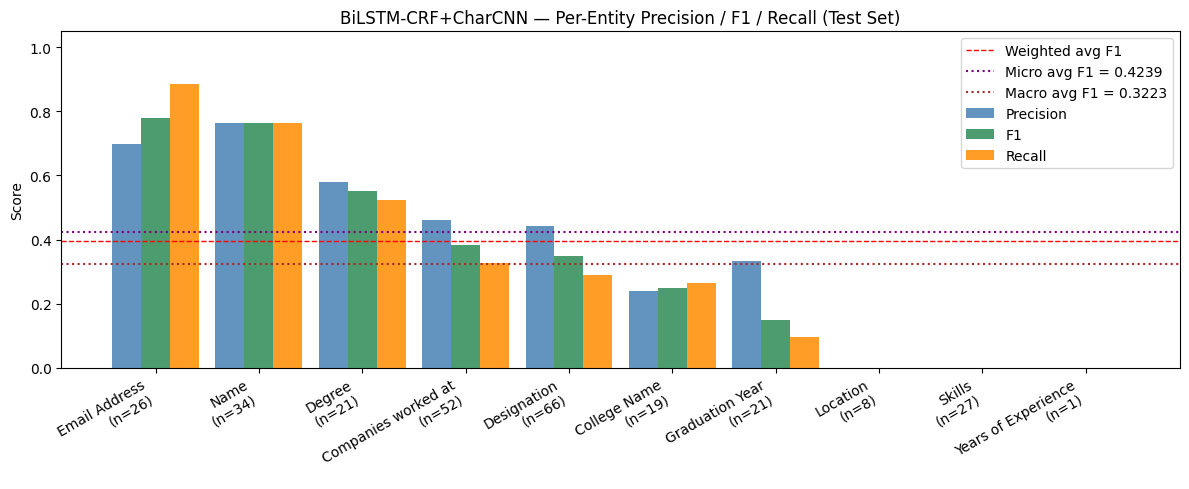

In [ ]:
# Load saved results
with open('model_result/results_bilstm_crf_char.pkl', 'rb') as f:
    results = pickle.load(f)

# Wrap jadi 1 sequence panjang (seqeval tetap bisa handle)
y_test      = [y_true_raw]
y_pred_test = [y_pred_raw]

report_dict = seq_report(y_test, y_pred_test, digits=4, output_dict=True)

micro_f1 = report_dict['micro avg']['f1-score']
macro_f1 = report_dict['macro avg']['f1-score']

per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
labels_sorted_with_n = [
    f"{k}\n(n={per_label[k]['support']})" 
    for k in labels_sorted
]
f1_scores     = [per_label[k]['f1-score'] for k in labels_sorted]
precision     = [per_label[k]['precision'] for k in labels_sorted]
recall        = [per_label[k]['recall']    for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels_sorted))
w = 0.28
ax.bar([i - w for i in x], precision, width=w, label='Precision', color='steelblue', alpha=0.85)
ax.bar(list(x),            f1_scores, width=w, label='F1',        color='seagreen',  alpha=0.85)
ax.bar([i + w for i in x], recall,    width=w, label='Recall',    color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted_with_n, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('BiLSTM-CRF+CharCNN — Per-Entity Precision / F1 / Recall (Test Set)')
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0), color='red',    linestyle='--', linewidth=1,   label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':', linewidth=1.5, label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline(macro_f1, color='brown',  linestyle=':', linewidth=1.5, label=f'Macro avg F1 = {macro_f1:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

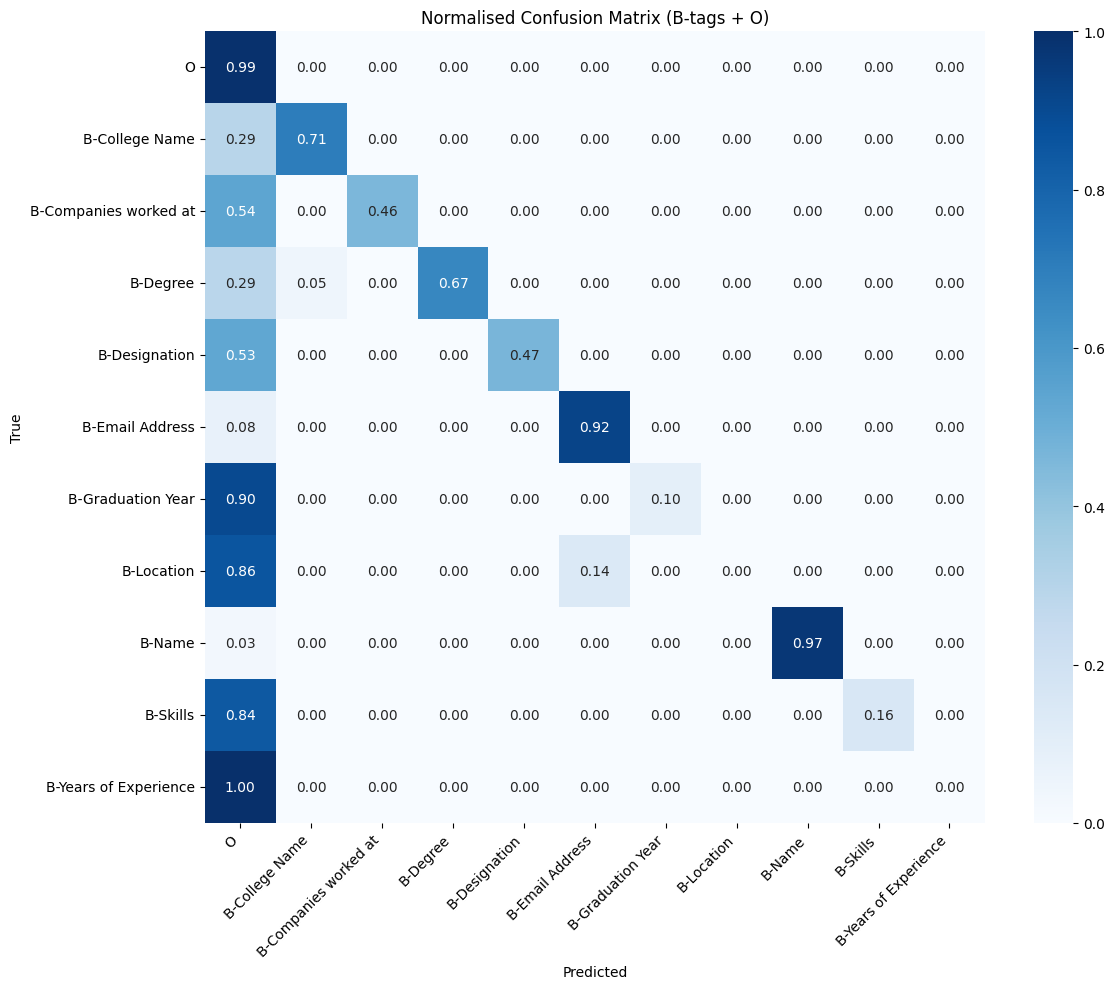

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ambil semua unique labels (B-tags + O)
all_labels = ['O'] + [l for l in sorted(set(y_true_raw)) if l.startswith('B-')]

# Buat confusion matrix
cm = confusion_matrix(y_true_raw, y_pred_raw, labels=all_labels)

# Normalize per row (true label)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)  # handle division by zero

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=all_labels,
    yticklabels=all_labels,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Normalised Confusion Matrix (B-tags + O)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()